# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sujithauday/flyrank-ml-internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

*Name your lane — or say 'freestyle' and describe your own question. One short paragraph: why this one?*

Lane: CTR / Engagement Opportunity Scoring
Tye:	Core lane
Default dataset: warehouse release or starter dataset
Output: Ranked opportunity score; position/volume adjusted



In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

*What decision does your work improve? Who acts on it? What does a wrong recommendation cost?*

Question: Which pages should the SEO/content team improve first?
Decision:
Action: To rank content pages that have the highest opportunity to improve engagement.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv")
print(df.head(3))
print(df.columns.tolist())

             content_id          client_id  search_volume  competition  \
0  content_304f48230142  client_f369cb89fc           10.0         0.67   
1  content_a1fb4e703a9e  client_4e07408562           90.0         0.01   
2  content_9aa793d4d895  client_7f2253d7e2            0.0         0.00   

  competition_level   cpc     content_type    main_intent  word_count  \
0              HIGH  2.05  keyword article  transactional      3221.0   
1               LOW  0.05  keyword article  informational      2481.0   
2               LOW  0.00  keyword article  informational      3515.0   

   char_count  ... char_count_tier   ctr  avg_position  engagement_rate  \
0     20457.0  ...     15000-25000  0.76          10.6             5.88   
1     15562.0  ...     15000-25000  0.05          20.3             0.00   
2     23643.0  ...     15000-25000  0.09          36.5             0.00   

   scroll_rate  ai_traffic_pct  impression_tier  position_tier  \
0         4.55             0.0             

In [3]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().reset_index()
ctr_by_pos_share = ctr_by_pos["ctr"]/ctr_by_pos["ctr"].sum() *100
print(ctr_by_pos_share)
print(ctr_by_pos)


0     4.850591
1    31.052718
2    12.460915
3    22.389019
4    29.246758
Name: ctr, dtype: float64
  position_tier       ctr
0          deep  0.055415
1        page_1  0.354760
2      page_3_5  0.142359
3      striking  0.255782
4         top_3  0.334128


In [9]:
# high search volume - more traffic
corr = df["engaged_sessions_90d"].corr(df["clicks_90d"])
print(f"Correlation between engaged_sessions_90d and clicks_90d: {corr:.3f}")
corr = df["engaged_sessions_90d"].corr(df["ctr"])
print(f"Correlation between engagement_sessions_90d and ctr: {corr:.3f}")
corr = df["search_volume"].corr(df["clicks_90d"])
print(f"Correlation between search_volume and clicks_90d: {corr:.3f}")

Correlation between engaged_sessions_90d and clicks_90d: 0.734
Correlation between engagement_sessions_90d and ctr: 0.009
Correlation between search_volume and clicks_90d: -0.011


In [6]:
#df[["avg_position", "ctr"]].corr()
df["avg_position"].corr(df["ctr"])

np.float64(-0.07259029976832464)

<Axes: xlabel='avg_position', ylabel='ctr'>

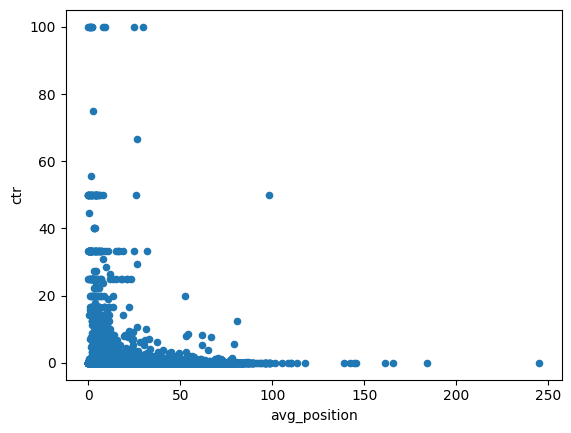

In [4]:
df.plot.scatter(x="avg_position", y="ctr")


In [5]:
import statsmodels.api as sm

X = df["avg_position"]
y = df["ctr"]

# Add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

# Does avg_position has impact on ctr?
#

                            OLS Regression Results                            
Dep. Variable:                    ctr   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     158.9
Date:                Mon, 27 Jul 2026   Prob (F-statistic):           2.42e-36
Time:                        04:34:39   Log-Likelihood:                -78116.
No. Observations:               30000   AIC:                         1.562e+05
Df Residuals:                   29998   BIC:                         1.563e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.7664      0.028     27.657   

In [6]:
df.corr(numeric_only=True)["ctr"].sort_values(ascending=False)

,ctr
ctr,1.000000
engagement_rate,0.096903
scroll_rate,0.012955
clicks_90d,0.010609
clicks_prev_30d,0.010217
content_age_days,0.009460
engaged_sessions_90d,0.009096
clicks_last_30d,0.009027
age_tier_order,0.008387
trend_pct,0.007968


In [7]:
import statsmodels.api as sm

X = df[["avg_position", "impressions", "clicks", "trend_strength"]]
X = sm.add_constant(X)
y = df["ctr"]

model = sm.OLS(y, X).fit()
print(model.summary())

KeyError: "['impressions', 'clicks', 'trend_strength'] not in index"

## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# print(f"{visibility:.3f}")
visibility1  = df [df["trend_direction"] == "down"]
visibility = (visibility1.groupby("position_tier")["ctr"]
              .mean()
              .reset_index())

print(visibility.sort_values(by ="ctr", ascending = False))


ctr_share = visibility["ctr"] / visibility["ctr"].sum() *100
print(ctr_share)


  position_tier       ctr
4         top_3  1.165349
1        page_1  0.434952
3      striking  0.234394
2      page_3_5  0.153966
0          deep  0.050154
0     2.459967
1    21.333590
2     7.551743
3    11.496557
4    57.158143
Name: ctr, dtype: float64


In [8]:
df["impression_tier_numeric"] = df["impression_tier"].astype("category").cat.codes
df[["impression_tier_numeric", "engagement_rate", "ctr"]].corr()

,impression_tier_numeric,engagement_rate,ctr
impression_tier_numeric,1.000000,-0.025436,-0.014705
engagement_rate,-0.025436,1.000000,0.096903
ctr,-0.014705,0.096903,1.000000


In [5]:
# high engagement rate mean high scroll rate

corr = df["engaged_sessions_90d"].corr(df["scroll_events_90d"])
print(f"Correlation between engaged_sessions_90d and scroll_events_90d: {corr:.3f}")

Correlation between engaged_sessions_90d and scroll_events_90d: 0.437


In [17]:
visibility = (df.groupby(["position_tier", "trend_direction"])["ctr"]
              .mean()
              .reset_index())

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.